# UHM Downsampled — Augment Decimated Index with Missing Landmarks

Some of the 68 UHM landmarks are not present in the decimated vertex set.
This notebook identifies those missing landmarks and appends their full-model
vertex indices to the decimated downsample index, producing an augmented index
where all 68 landmarks are guaranteed to appear.

**Files used**
- `decimated_downsample_indices.npy` — shape `(N_dec,)` — maps decimated vertex `i` → full-model vertex index
- `head_model_global_align_no_mouth_and_eyes.pkl` — full UHM model; `Mean` gives the mean shape `(71 926, 3)`
- `light_model_68_land_idxs.pkl` — 68 landmark indices in full-model vertex space

In [1]:
import os
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=DeprecationWarning)

## 1 — Load data

In [2]:
DOWNSAMPLE_IDX_PATH = '/data/datasets/UHM_generated_data/decimated_downsample_indices.npy'
UHM_MODEL_PATH      = '/data/UHM_models/head_model_global_align_no_mouth_and_eyes.pkl'
LANDMARK_IDXS_PATH  = '/data/UHM_models/Landmarks and masks/light_model_68_land_idxs.pkl'

# Decimated → full vertex mapping
ds_idx = np.load(DOWNSAMPLE_IDX_PATH)          # (N_dec,)

# Full UHM mean shape
with open(UHM_MODEL_PATH, 'rb') as f:
    uhm = pickle.load(f)
mean_shape = uhm['Mean'].reshape(-1, 3)         # (71 926, 3)

# 68-landmark indices in full model
with open(LANDMARK_IDXS_PATH, 'rb') as f:
    lm_full_idxs = pickle.load(f)               # (68,)

print(f'Full model vertices  : {mean_shape.shape}')
print(f'Decimated vertices   : {ds_idx.shape}')
print(f'Landmark indices (68): {lm_full_idxs.shape}')

/tmp/ipykernel_1825526/4048081772.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  uhm = pickle.load(f)


Full model vertices  : (71926, 3)
Decimated vertices   : (10859,)
Landmark indices (68): (68,)


## 2 — Find missing landmarks and augment the decimated index

In [3]:
ds_idx_set = set(ds_idx.tolist())

# Which landmarks are already in the decimated index, which are missing?
present_mask = np.array([idx in ds_idx_set for idx in lm_full_idxs])
missing_lm_full_idxs = lm_full_idxs[~present_mask]   # full-model vertex indices to add

print(f'Landmarks already in decimated index : {present_mask.sum()} / 68')
print(f'Landmarks missing (to be added)      : {(~present_mask).sum()} / 68')
print(f'Missing landmark numbers             : {np.where(~present_mask)[0].tolist()}')
print(f'Missing full-model vertex indices    : {missing_lm_full_idxs.tolist()}')

Landmarks already in decimated index : 6 / 68
Landmarks missing (to be added)      : 62 / 68
Missing landmark numbers             : [0, 1, 2, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67]
Missing full-model vertex indices    : [59522, 29677, 29672, 21593, 55585, 7662, 1565, 30010, 50696, 35067, 25162, 49928, 45743, 45942, 66268, 14024, 5521, 2014, 8501, 1869, 67039, 67033, 23558, 46827, 26491, 2178, 22228, 31308, 31338, 70760, 71510, 58269, 36495, 13507, 60772, 1148, 930, 28559, 10759, 56113, 9368, 10652, 33125, 18924, 8985, 56041, 57999, 26871, 35895, 51431, 58133, 2152, 22146, 30368, 27697, 15665, 70797, 17896, 3128, 53430, 31317, 64747]


In [4]:
# Append missing landmark vertices at the end of the decimated index
augmented_ds_idx = np.concatenate([ds_idx, missing_lm_full_idxs])

print(f'Original decimated index size : {len(ds_idx)}')
print(f'Added vertices                : {len(missing_lm_full_idxs)}')
print(f'Augmented index size          : {len(augmented_ds_idx)}')

Original decimated index size : 10859
Added vertices                : 62
Augmented index size          : 10921


## 3 — Resolve landmark indices in the augmented index

In [5]:
# Build full-vertex → augmented-index lookup
full_to_aug = {v: i for i, v in enumerate(augmented_ds_idx)}

lm_aug_idxs = np.array([full_to_aug[v] for v in lm_full_idxs])

print('Landmark indices in augmented decimated template:')
print(lm_aug_idxs)

print(f'\n{"LM":>4}  {"Full-model idx":>16}  {"Aug. dec. idx":>14}  {"Status":>12}')
print('-' * 56)
for i, (fi, ai, missing) in enumerate(zip(lm_full_idxs, lm_aug_idxs, ~present_mask)):
    status = '<-- added' if missing else 'present'
    print(f'{i:>4}  {fi:>16}  {ai:>14}  {status:>12}')

Landmark indices in augmented decimated template:
[10859 10860 10861  9581 10862 10863 10864 10865 10866 10867  9062 10868
 10869 10870 10871 10872 10873 10874 10875 10876 10877 10878 10879 10880
 10881 10882  7716 10883 10884 10885 10886  7273 10887 10888 10889 10890
 10891 10892 10893 10894 10895 10896 10897  5568 10898 10899 10900 10901
 10902 10903 10904 10905 10906 10907  2862 10908 10909 10910 10911 10912
 10913 10914 10915 10916 10917 10918 10919 10920]

  LM    Full-model idx   Aug. dec. idx        Status
--------------------------------------------------------
   0             59522           10859     <-- added
   1             29677           10860     <-- added
   2             29672           10861     <-- added
   3             62110            9581       present
   4             21593           10862     <-- added
   5             55585           10863     <-- added
   6              7662           10864     <-- added
   7              1565           10865     <-- added


## 4 — Visualize landmarks on the augmented decimated template

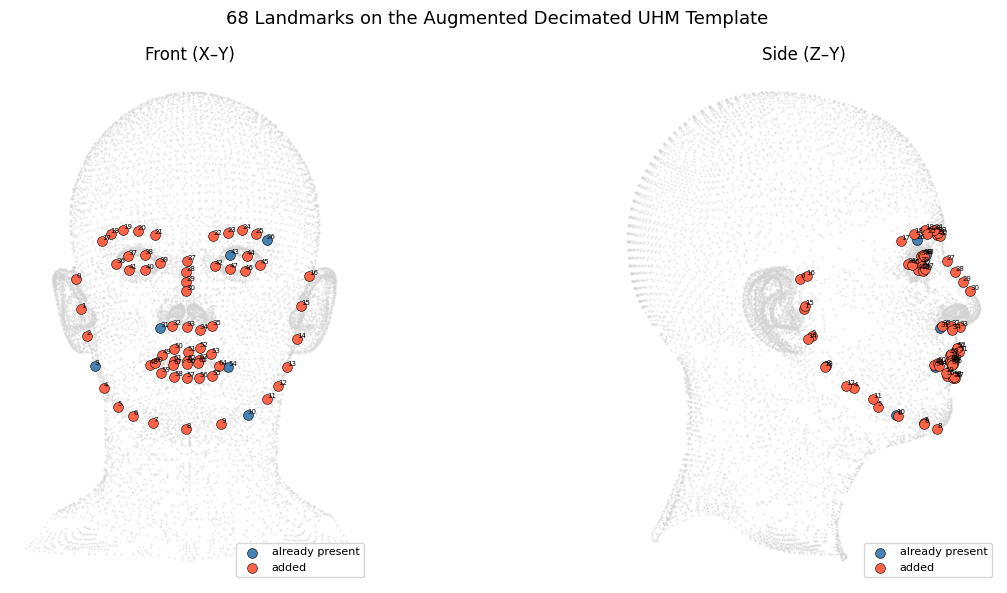

In [6]:
aug_pts = mean_shape[augmented_ds_idx]   # (N_aug, 3)
lm_pts  = aug_pts[lm_aug_idxs]          # (68, 3)

fig = plt.figure(figsize=(14, 6))

for ax_idx, (xi, yi, title) in enumerate([(0, 1, 'Front (X–Y)'), (2, 1, 'Side (Z–Y)')]):
    ax = fig.add_subplot(1, 2, ax_idx + 1)
    ax.scatter(aug_pts[:, xi], aug_pts[:, yi], s=0.5, c='lightgrey', alpha=0.4, rasterized=True)
    for is_missing, color, label in [(False, 'steelblue', 'already present'), (True, 'tomato', 'added')]:
        mask = ~present_mask if is_missing else present_mask
        ax.scatter(
            lm_pts[mask, xi], lm_pts[mask, yi],
            c=color, s=50, zorder=3, edgecolors='k', linewidths=0.4, label=label
        )
    for i, (x, y) in enumerate(zip(lm_pts[:, xi], lm_pts[:, yi])):
        ax.text(x, y, str(i), fontsize=5, ha='left', va='bottom')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('68 Landmarks on the Augmented Decimated UHM Template', fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Save augmented index and landmark indices

In [7]:
BASE = './new_downsampled_dataset/'
os.makedirs(BASE, exist_ok=True)

aug_idx_path = BASE + 'decimated_downsample_indices_with_landmarks.npy'
lm_idx_path  = BASE + 'decimated_68_land_idxs_augmented.npy'

np.save(aug_idx_path, augmented_ds_idx)
np.save(lm_idx_path,  lm_aug_idxs)

print(f'Saved augmented downsample index ({augmented_ds_idx.shape}) → {aug_idx_path}')
print(f'Saved landmark indices in augmented index ({lm_aug_idxs.shape}) → {lm_idx_path}')

Saved augmented downsample index ((10921,)) → ./new_downsampled_dataset/decimated_downsample_indices_with_landmarks.npy
Saved landmark indices in augmented index ((68,)) → ./new_downsampled_dataset/decimated_68_land_idxs_augmented.npy


In [8]:
SELECTED_LANDMARKS = [0,2,8,14,16,54,51,57,48,31,35,33,27,42,45,26,22,17,21,36,39]

In [9]:
len(SELECTED_LANDMARKS)

21

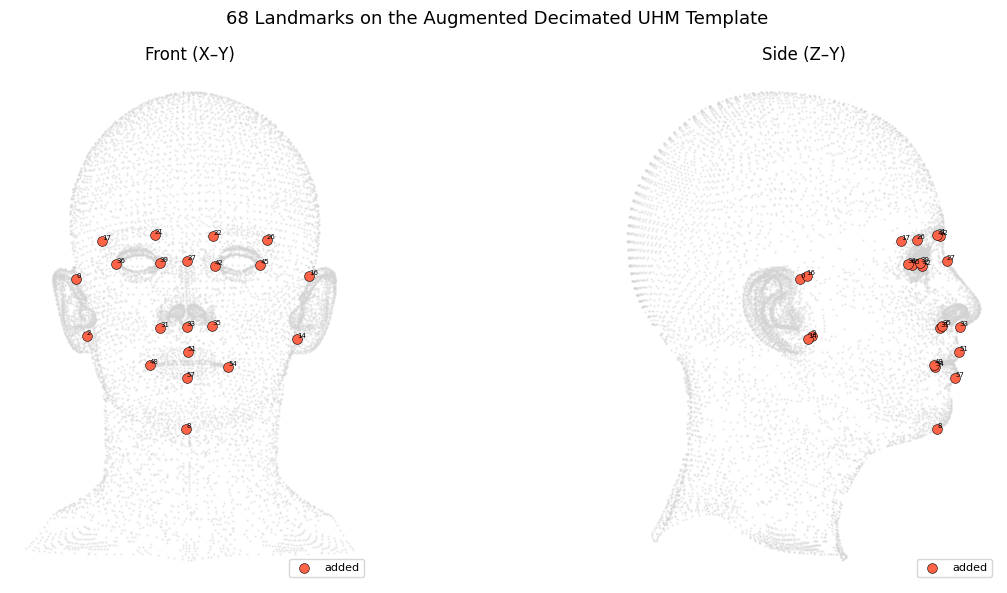

In [10]:
aug_pts = mean_shape[augmented_ds_idx]   # (N_aug, 3)
lm_pts  = aug_pts[lm_aug_idxs]          # (68, 3)
selected_lm_pts = lm_pts[SELECTED_LANDMARKS]  # (21, 3)
fig = plt.figure(figsize=(14, 6))

for ax_idx, (xi, yi, title) in enumerate([(0, 1, 'Front (X–Y)'), (2, 1, 'Side (Z–Y)')]):
    ax = fig.add_subplot(1, 2, ax_idx + 1)
    ax.scatter(aug_pts[:, xi], aug_pts[:, yi], s=0.5, c='lightgrey', alpha=0.4, rasterized=True)
    
    ax.scatter(
        lm_pts[SELECTED_LANDMARKS, xi], lm_pts[SELECTED_LANDMARKS, yi],
        c=color, s=50, zorder=3, edgecolors='k', linewidths=0.4, label=label
    )
    for i, (x, y) in enumerate(zip(selected_lm_pts[:, xi], selected_lm_pts[:, yi])):
        ax.text(x, y, str(SELECTED_LANDMARKS[i]), fontsize=5, ha='left', va='bottom')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('68 Landmarks on the Augmented Decimated UHM Template', fontsize=13)
plt.tight_layout()
plt.show()

# 6 — Recover `neighborhoods_new.py` patches and map them to the new downsample

`neighborhoods_new.py` defines 32 superpoints as vertex indices into the **old** downsampled
dataset (`/data/datasets/UHM_downsampled/train`, 10 788 vertices per face) and extracts a
patch of `k=700` nearest neighbors around each one on the template (first sorted file, `0.ply`).

The old and new downsamples are **different vertex subsets** of the full UHM model, but they
live in the **same coordinate frame** (bounding boxes match). Strategy:

1. Recover the old patches exactly as `neighborhoods_new.py` does (kNN on `0.ply`).
2. Compute the **per-vertex mean over the old training faces** — `0.ply` is a single random
   identity, while the new template `mean_shape[augmented_ds_idx]` is the UHM *mean* shape,
   so the old training mean is the right anchor for matching.
3. Map each superpoint to its nearest vertex in the new augmented decimated template.
4. Re-extract the patches (kNN, same k) on the new template and visualize both side by side.

In [11]:
import os
import open3d as o3d
from scipy.spatial import cKDTree

OLD_SRC = '/data/datasets/UHM_downsampled/train'
K_NEIGHBORS = 700

# 32 superpoint indices from neighborhoods_new.py (old-downsample vertex space)
SUPERPOINT_INDICES = [75, 411, 2699, 911, 8594, 3380, 6731, 9710, 9633, 119,
                      3441, 6319, 9541, 8732, 6162, 3774, 8296, 3151, 10,
                      7720, 6858, 7409, 7531, 3504, 6937, 4189, 8891, 3721,
                      9241, 2213, 1765, 7547]

old_files = sorted(f for f in os.listdir(OLD_SRC) if f.endswith('.ply'))

# Template used by neighborhoods_new.py: first sorted file
old_template = np.asarray(
    o3d.io.read_point_cloud(os.path.join(OLD_SRC, old_files[0])).points)

# Per-vertex mean over a subsample of the old training faces (all files share topology)
MEAN_STRIDE = 10  # 8000 files -> 800 faces; lower for more accuracy
acc = None
for f in old_files[::MEAN_STRIDE]:
    pts = np.asarray(o3d.io.read_point_cloud(os.path.join(OLD_SRC, f)).points)
    acc = pts if acc is None else acc + pts
old_mean = acc / len(old_files[::MEAN_STRIDE])

print(f'Old files                : {len(old_files)} (template: {old_files[0]})')
print(f'Old template vertices    : {old_template.shape}')
print(f'Old mean (over {len(old_files[::MEAN_STRIDE])} faces): {old_mean.shape}')
print(f'Old mean bbox            : {old_mean.min(0).round(3)} .. {old_mean.max(0).round(3)}')
print(f'New template bbox        : {aug_pts.min(0).round(3)} .. {aug_pts.max(0).round(3)}')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Old files                : 8000 (template: 0.ply)
Old template vertices    : (10788, 3)
Old mean (over 800 faces): (10788, 3)
Old mean bbox            : [-0.86  -1.31  -1.317] .. [0.898 1.251 0.617]
New template bbox        : [-0.886 -1.311 -1.315] .. [0.907 1.255 0.619]


In [12]:
# --- 6.1 Recover the old patches exactly as neighborhoods_new.py does ---
old_tree = cKDTree(old_template)
old_patches = np.stack([
    old_tree.query(old_template[sp], k=K_NEIGHBORS)[1]
    for sp in SUPERPOINT_INDICES
])  # (32, 700) indices into the old downsample
print(f'Recovered old patches: {old_patches.shape}')

# --- 6.2 Map superpoints to the new augmented decimated template ---
# Match on the old training MEAN (same frame as mean_shape) -> nearest new vertex
aug_tree = cKDTree(aug_pts)
spacing = np.median(aug_tree.query(aug_pts, k=2)[0][:, 1])

map_dists, sp_new_idxs = aug_tree.query(old_mean[SUPERPOINT_INDICES])

print(f'New template median point spacing: {spacing:.4f}')
print(f'Mapping distance: median {np.median(map_dists):.4f}, max {map_dists.max():.4f}')
print(f'Unique new indices: {len(np.unique(sp_new_idxs))} / {len(sp_new_idxs)}\n')

print(f'{"#":>3}  {"old idx":>8}  {"new idx":>8}  {"dist":>8}  {"dist/spacing":>12}')
print('-' * 48)
for i, (so, sn, d) in enumerate(zip(SUPERPOINT_INDICES, sp_new_idxs, map_dists)):
    print(f'{i:>3}  {so:>8}  {sn:>8}  {d:>8.4f}  {d/spacing:>12.2f}')

# --- 6.3 Re-extract the patches on the new template ---
new_patches = np.stack([
    aug_tree.query(aug_pts[sn], k=K_NEIGHBORS)[1]
    for sn in sp_new_idxs
])  # (32, 700) indices into the augmented decimated downsample
print(f'\nNew patches: {new_patches.shape}')

Recovered old patches: (32, 700)
New template median point spacing: 0.0169
Mapping distance: median 0.0064, max 0.0411
Unique new indices: 32 / 32

  #   old idx   new idx      dist  dist/spacing
------------------------------------------------
  0        75      3370    0.0142          0.84
  1       411       549    0.0003          0.02
  2      2699      8649    0.0040          0.24
  3       911      2498    0.0076          0.45
  4      8594     10133    0.0043          0.25
  5      3380      5254    0.0054          0.32
  6      6731      1548    0.0065          0.38
  7      9710      7186    0.0069          0.40
  8      9633      8501    0.0315          1.86
  9       119      7025    0.0027          0.16
 10      3441      3889    0.0007          0.04
 11      6319      6894    0.0011          0.06
 12      9541      7068    0.0165          0.98
 13      8732      8432    0.0156          0.92
 14      6162      9548    0.0099          0.59
 15      3774     10368    0.0385  

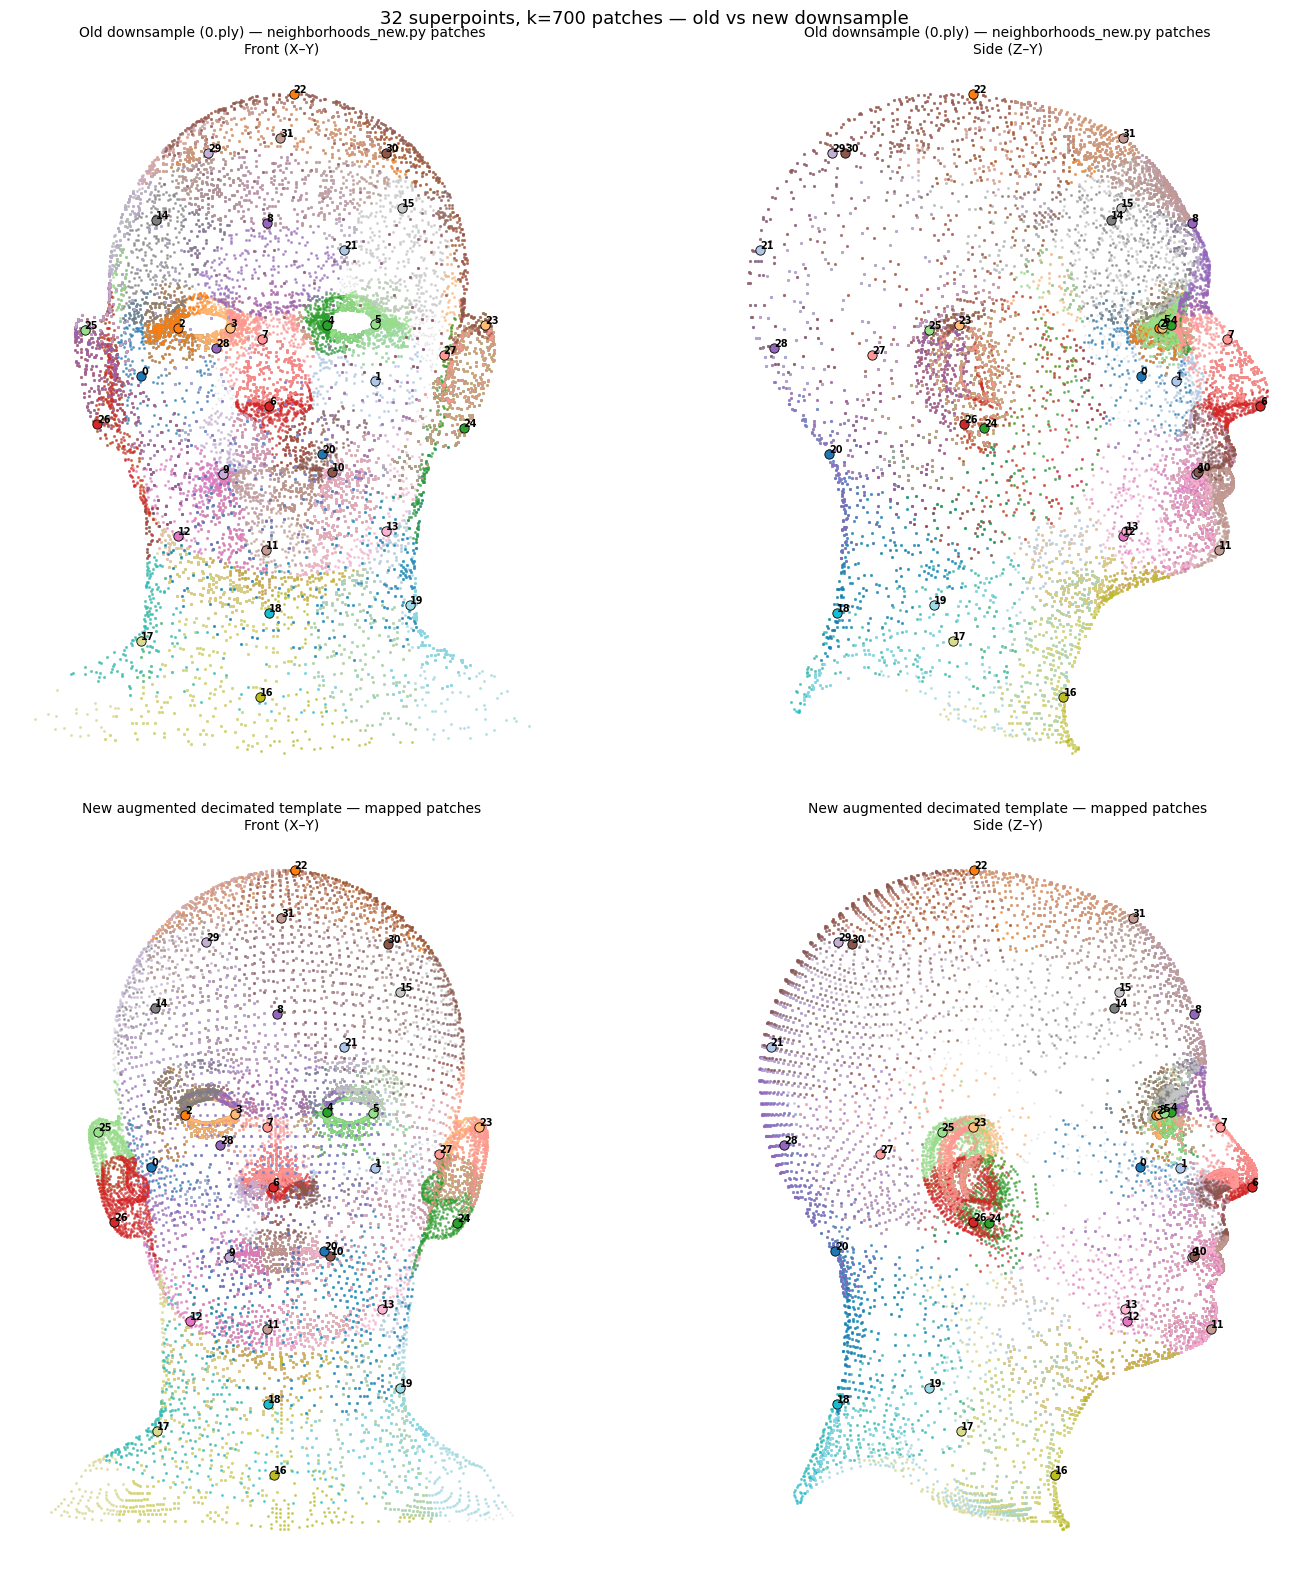

In [13]:
# --- 6.4 Visualize: old patches (on 0.ply) vs mapped patches (on new template) ---
cmap = plt.get_cmap('tab20')
n_sp = len(SUPERPOINT_INDICES)

views = [(0, 1, 'Front (X–Y)'), (2, 1, 'Side (Z–Y)')]
configs = [
    ('Old downsample (0.ply) — neighborhoods_new.py patches',
     old_template, old_patches, SUPERPOINT_INDICES),
    ('New augmented decimated template — mapped patches',
     aug_pts, new_patches, sp_new_idxs),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for row, (title, pts, patches, sps) in enumerate(configs):
    for col, (xi, yi, view) in enumerate(views):
        ax = axes[row, col]
        ax.scatter(pts[:, xi], pts[:, yi], s=0.5, c='lightgrey', alpha=0.4, rasterized=True)
        for i, (patch, sp) in enumerate(zip(patches, sps)):
            color = cmap(i % 20)
            ax.scatter(pts[patch, xi], pts[patch, yi], s=1.5, color=color,
                       alpha=0.5, rasterized=True)
            ax.scatter(pts[sp, xi], pts[sp, yi], s=45, color=color, zorder=3,
                       edgecolors='k', linewidths=0.6)
            ax.text(pts[sp, xi], pts[sp, yi], str(i), fontsize=7, fontweight='bold',
                    ha='left', va='bottom', zorder=4)
        ax.set_title(f'{title}\n{view}', fontsize=10)
        ax.set_aspect('equal')
        ax.axis('off')

plt.suptitle(f'32 superpoints, k={K_NEIGHBORS} patches — old vs new downsample', fontsize=13)
plt.tight_layout()
plt.show()

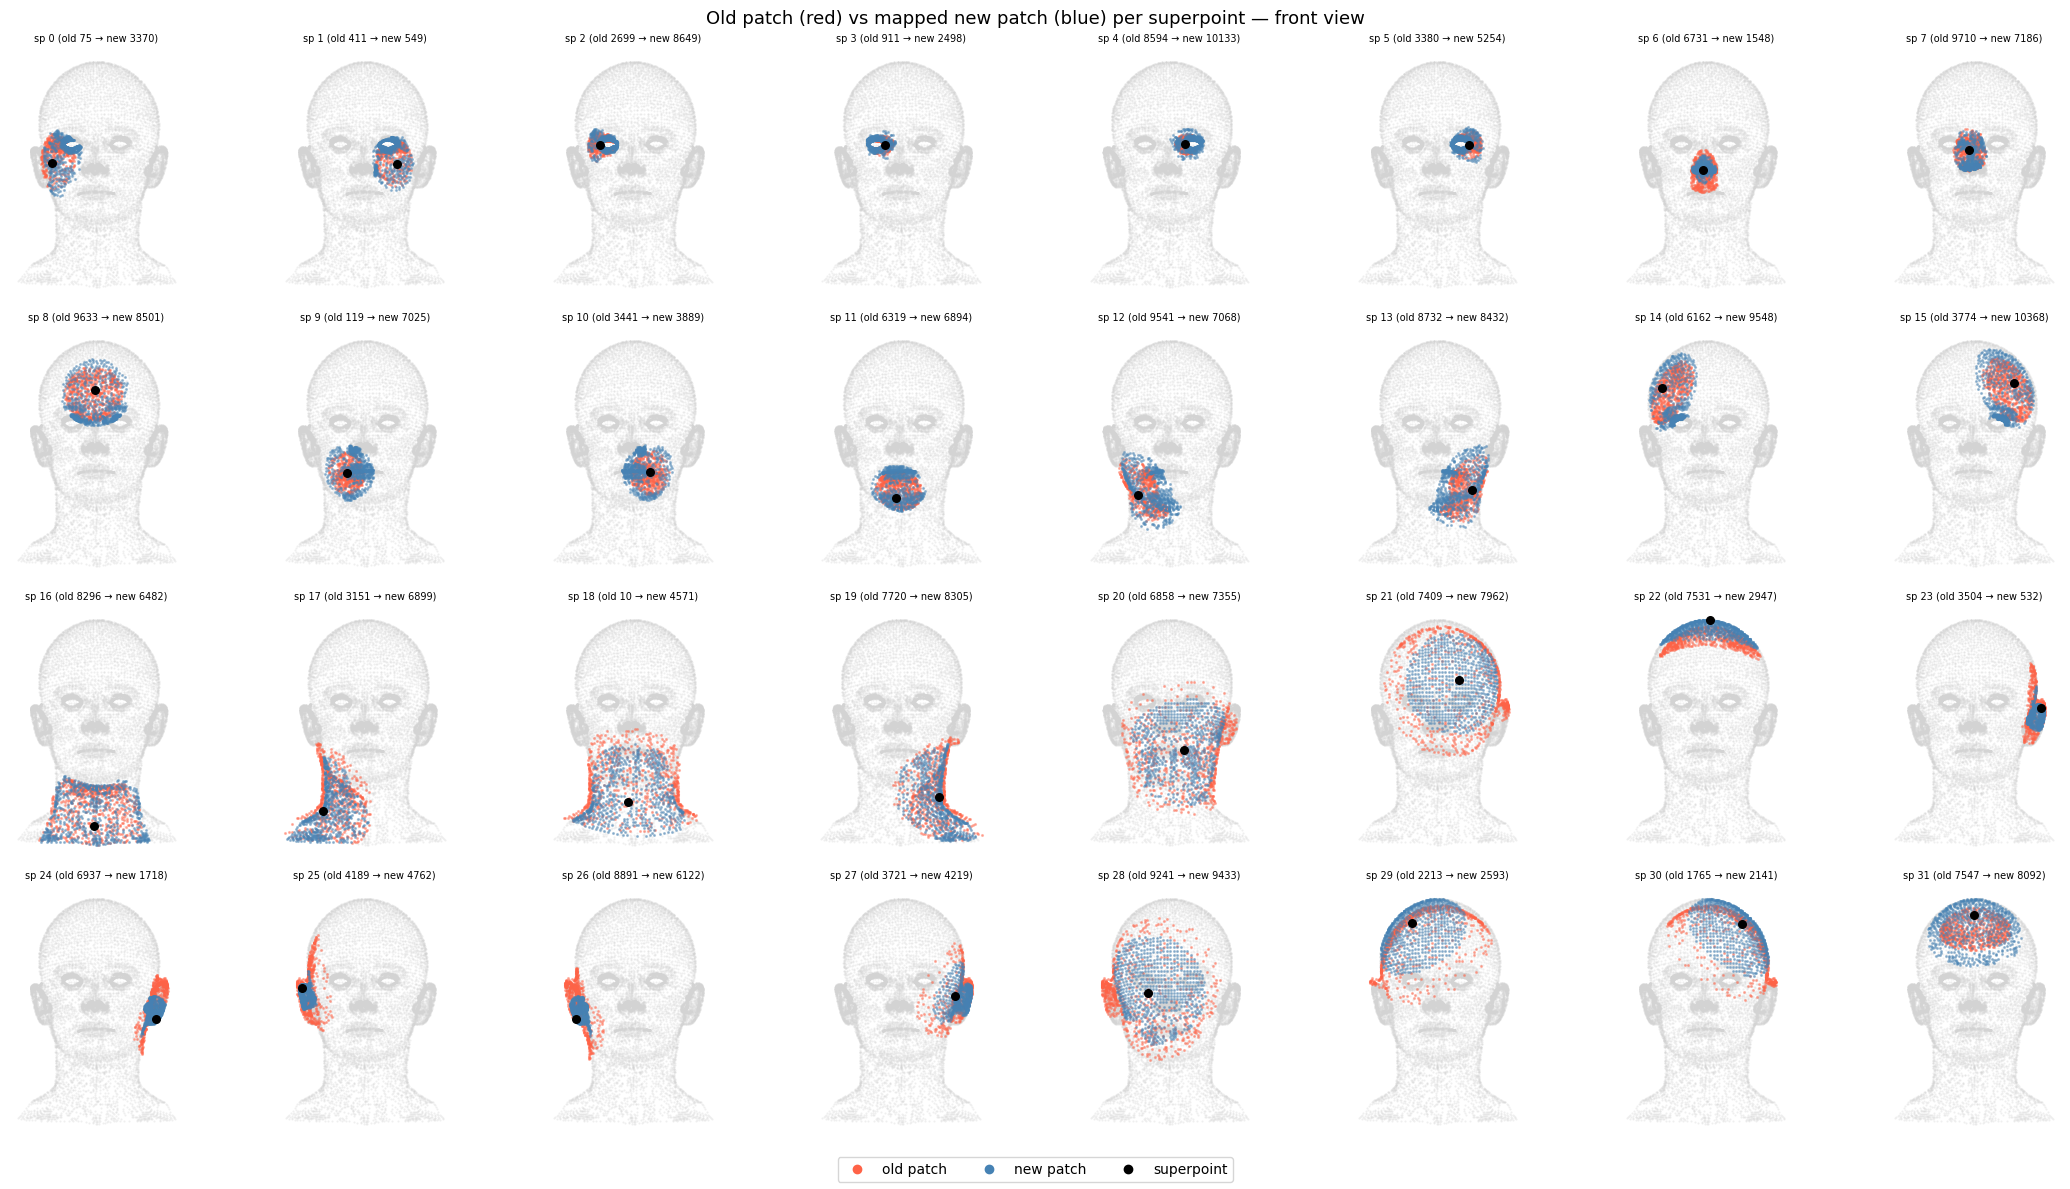

In [14]:
# --- 6.5 Per-patch comparison grid: each old patch vs its mapped new patch (front view) ---
fig, axes = plt.subplots(4, 8, figsize=(22, 12))
for i, ax in enumerate(axes.flat):
    ax.scatter(aug_pts[:, 0], aug_pts[:, 1], s=0.3, c='lightgrey', alpha=0.3, rasterized=True)
    op = old_template[old_patches[i]]
    ax.scatter(op[:, 0], op[:, 1], s=1.5, c='tomato', alpha=0.4, rasterized=True, label='old')
    np_ = aug_pts[new_patches[i]]
    ax.scatter(np_[:, 0], np_[:, 1], s=1.5, c='steelblue', alpha=0.4, rasterized=True, label='new')
    ax.scatter(*aug_pts[sp_new_idxs[i], :2], s=30, c='k', zorder=3)
    ax.set_title(f'sp {i} (old {SUPERPOINT_INDICES[i]} → new {sp_new_idxs[i]})', fontsize=7)
    ax.set_aspect('equal')
    ax.axis('off')

handles = [plt.Line2D([], [], marker='o', ls='', c=c, label=l)
           for c, l in [('tomato', 'old patch'), ('steelblue', 'new patch'), ('k', 'superpoint')]]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10)
plt.suptitle('Old patch (red) vs mapped new patch (blue) per superpoint — front view', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [15]:
# --- 6.6 Save mapped superpoint indices and patches for the new downsample ---
sp_path      = BASE + 'superpoint_indices_new_downsample.npy'
patches_path = BASE + 'superpoint_patches_new_downsample.npy'

np.save(sp_path, sp_new_idxs)
np.save(patches_path, new_patches)

print(f'Saved mapped superpoint indices {sp_new_idxs.shape} → {sp_path}')
print(f'Saved new patches {new_patches.shape} → {patches_path}')

Saved mapped superpoint indices (32,) → ./new_downsampled_dataset/superpoint_indices_new_downsample.npy
Saved new patches (32, 700) → ./new_downsampled_dataset/superpoint_patches_new_downsample.npy


# 7 — Analytic patch PCA from the UHM model vs sample-based patch PCA

The UHM model gives the population covariance of any vertex subset analytically:
for patch coordinate rows $p$, $C_p = E_p \Lambda E_p^\top$ where $E_p$ are the
corresponding rows of `Eigenvectors` and $\Lambda = \mathrm{diag}($`EigenValues`$)$.
Its nonzero eigenvalues are those of the $500\times500$ matrix
$\Lambda^{1/2} E_p^\top E_p \Lambda^{1/2}$ — no sampling needed.

We compare three spectra per patch:

| | vertices | covariance |
|---|---|---|
| **A. sample (old)** | old patch (`neighborhoods_new.py`) | sample covariance over the old training faces (this is what `pca_demo.py` fits) |
| **B. model (old verts)** | same old patch vertices, mapped to full-model indices | analytic $E_p \Lambda E_p^\top$ |
| **C. model (new patch)** | mapped patch on the new augmented decimated template | analytic $E_p \Lambda E_p^\top$ |

A vs B isolates *generation/sampling* effects (should be ≈ 1 if the dataset was drawn
from the model). A vs C is the quantity of interest: how the spectrum changes when
moving the patches to the new downsample.

In [16]:
# --- 7.1 Load model PCA basis and all old training faces ---
E   = uhm['Eigenvectors']            # (215778, 500)
lam = uhm['EigenValues']             # (500,) variances per mode
sqlam = np.sqrt(lam)
n_modes = lam.shape[0]

SAMPLE_STRIDE = 1   # 1 = all 8000 faces (~5 min); increase for a quick pass

sample_files = old_files[::SAMPLE_STRIDE]
faces = np.empty((len(sample_files), old_template.shape[0], 3), dtype=np.float32)
for i, f in enumerate(sample_files):
    faces[i] = np.asarray(o3d.io.read_point_cloud(os.path.join(OLD_SRC, f)).points)
print(f'Loaded {faces.shape[0]} training faces: {faces.shape}')

# Old downsample -> full model vertex mapping via the training mean.
# (The old downsample is an exact vertex subset of the full model: NN dists ~1e-3.)
old_mean_full = faces.mean(axis=0, dtype=np.float64)
d_o2f, old2full = cKDTree(mean_shape).query(old_mean_full)
print(f'old->full vertex map: median dist {np.median(d_o2f):.2e}, max {d_o2f.max():.2e}, '
      f'unique {len(np.unique(old2full))}/{len(old2full)}')

Loaded 8000 training faces: (8000, 10788, 3)
old->full vertex map: median dist 2.55e-04, max 8.11e-04, unique 10786/10788


In [17]:
# --- 7.2 Compute the three spectra for every patch ---
def model_patch_eigvals(full_verts):
    """Nonzero eigenvalues of E_p Λ E_pᵀ for the given full-model vertex indices."""
    rows = np.stack([3 * full_verts, 3 * full_verts + 1, 3 * full_verts + 2], axis=1).ravel()
    Ep = E[rows] * sqlam                       # (3k, 500) = E_p Λ^{1/2}
    return np.linalg.eigvalsh(Ep.T @ Ep)[::-1]  # (500,) descending

n_sp = len(SUPERPOINT_INDICES)
ev_sample    = np.empty((n_sp, n_modes))  # A: sample PCA, old patches
ev_model_old = np.empty((n_sp, n_modes))  # B: analytic, same old patch vertices
ev_model_new = np.empty((n_sp, n_modes))  # C: analytic, new mapped patches

n_faces = faces.shape[0]
for pi in range(n_sp):
    X = faces[:, old_patches[pi], :].reshape(n_faces, -1).astype(np.float64)
    Xc = X - X.mean(axis=0)
    C = Xc.T @ Xc / (n_faces - 1)              # same convention as sklearn PCA
    ev_sample[pi] = np.linalg.eigvalsh(C)[::-1][:n_modes]

    ev_model_old[pi] = model_patch_eigvals(old2full[old_patches[pi]])
    ev_model_new[pi] = model_patch_eigvals(augmented_ds_idx[new_patches[pi]])

print(f'Spectra computed: {ev_sample.shape} (sample A), '
      f'{ev_model_old.shape} (model-old B), {ev_model_new.shape} (model-new C)')

Spectra computed: (32, 500) (sample A), (32, 500) (model-old B), (32, 500) (model-new C)


In [18]:
# --- 7.3 Per-patch comparison table ---
TOP_K = 30  # pca_demo.py keeps 30 components

tot_s, tot_mo, tot_mn = ev_sample.sum(1), ev_model_old.sum(1), ev_model_new.sum(1)
# median relative eigenvalue difference over the top-K modes
rel_AB = np.median(np.abs(ev_sample[:, :TOP_K] - ev_model_old[:, :TOP_K]) / ev_model_old[:, :TOP_K], axis=1)
rel_AC = np.median(np.abs(ev_sample[:, :TOP_K] - ev_model_new[:, :TOP_K]) / ev_model_new[:, :TOP_K], axis=1)

print(f'{"#":>3} {"λ1 sample":>10} {"λ1 mod-old":>11} {"λ1 mod-new":>11} '
      f'{"Σλ A/B":>7} {"Σλ A/C":>7} {"med|Δ|/λ A·B":>13} {"med|Δ|/λ A·C":>13}')
print('-' * 82)
for pi in range(n_sp):
    print(f'{pi:>3} {ev_sample[pi,0]:>10.5f} {ev_model_old[pi,0]:>11.5f} {ev_model_new[pi,0]:>11.5f} '
          f'{tot_s[pi]/tot_mo[pi]:>7.3f} {tot_s[pi]/tot_mn[pi]:>7.3f} '
          f'{rel_AB[pi]:>12.1%} {rel_AC[pi]:>12.1%}')

print('-' * 82)
print(f'{"all":>3} {"":>10} {"":>11} {"":>11} '
      f'{np.median(tot_s/tot_mo):>7.3f} {np.median(tot_s/tot_mn):>7.3f} '
      f'{np.median(rel_AB):>12.1%} {np.median(rel_AC):>12.1%}   (medians)')

print(f'\nA vs B (same vertices, sample vs analytic): differences are pure sampling noise')
print(f'A vs C (old patches vs new patches): differences come from the vertex-set change')

  #  λ1 sample  λ1 mod-old  λ1 mod-new  Σλ A/B  Σλ A/C  med|Δ|/λ A·B  med|Δ|/λ A·C
----------------------------------------------------------------------------------
  0    0.16268     0.16950     0.21005   0.983   0.815         0.8%        31.3%
  1    0.15122     0.15801     0.17593   0.988   0.870         1.0%        29.6%
  2    0.22373     0.23389     0.27287   0.978   0.841         1.5%         8.2%
  3    0.28921     0.30372     0.28459   0.977   0.991         1.0%        48.2%
  4    0.26511     0.27563     0.23231   0.982   1.061         1.0%        44.9%
  5    0.16997     0.17688     0.22211   0.981   0.811         1.6%        17.2%
  6    0.17848     0.17714     0.25638   1.002   0.887         0.7%       107.5%
  7    0.16319     0.16607     0.19030   0.998   0.899         1.1%        17.2%
  8    0.47087     0.47260     0.32424   0.997   1.125         1.2%        43.1%
  9    0.26175     0.26318     0.20261   0.991   0.950         1.3%        35.3%
 10    0.25684     0.253

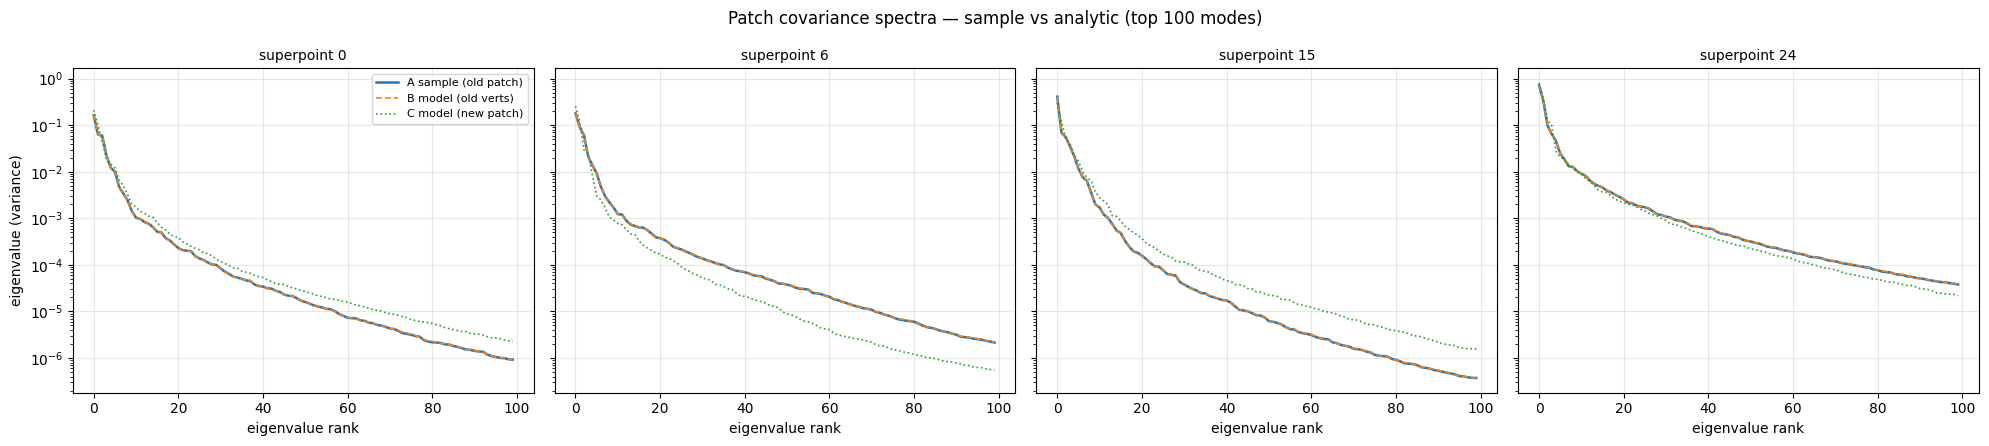

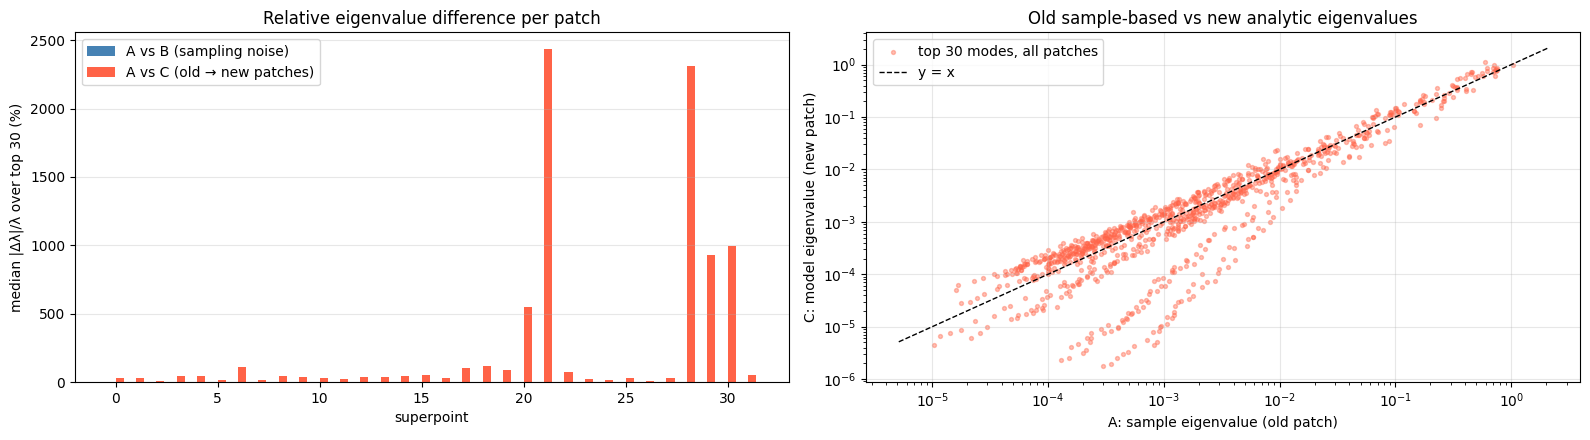

In [19]:
# --- 7.4 Spectra plots ---
# (a) full spectra for a few representative patches
show = [0, 6, 15, 24]
fig, axes = plt.subplots(1, len(show), figsize=(20, 4.5), sharey=True)
for ax, pi in zip(axes, show):
    ax.semilogy(ev_sample[pi, :100], label='A sample (old patch)', lw=1.8)
    ax.semilogy(ev_model_old[pi, :100], label='B model (old verts)', lw=1.2, ls='--')
    ax.semilogy(ev_model_new[pi, :100], label='C model (new patch)', lw=1.2, ls=':')
    ax.set_title(f'superpoint {pi}', fontsize=10)
    ax.set_xlabel('eigenvalue rank')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('eigenvalue (variance)')
axes[0].legend(fontsize=8)
plt.suptitle('Patch covariance spectra — sample vs analytic (top 100 modes)', fontsize=12)
plt.tight_layout()
plt.show()

# (b) per-patch summary of top-K relative differences
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
x = np.arange(n_sp)
axes[0].bar(x - 0.2, rel_AB * 100, width=0.4, label='A vs B (sampling noise)', color='steelblue')
axes[0].bar(x + 0.2, rel_AC * 100, width=0.4, label='A vs C (old → new patches)', color='tomato')
axes[0].set_xlabel('superpoint'); axes[0].set_ylabel(f'median |Δλ|/λ over top {TOP_K} (%)')
axes[0].set_title('Relative eigenvalue difference per patch')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].scatter(ev_sample[:, :TOP_K].ravel(), ev_model_new[:, :TOP_K].ravel(),
                s=8, alpha=0.4, c='tomato', label=f'top {TOP_K} modes, all patches')
lims = [ev_sample[:, :TOP_K].min() * 0.5, ev_sample[:, 0].max() * 2]
axes[1].plot(lims, lims, 'k--', lw=1, label='y = x')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('A: sample eigenvalue (old patch)')
axes[1].set_ylabel('C: model eigenvalue (new patch)')
axes[1].set_title('Old sample-based vs new analytic eigenvalues')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# --- 7.5 Save the analytic eigenvalues for the new patches ---
ev_new_path = BASE + 'superpoint_patch_model_eigvals_new_downsample.npy'
ev_old_sample_path = BASE + 'superpoint_patch_sample_eigvals_old_downsample.npy'

np.save(ev_new_path, ev_model_new)
np.save(ev_old_sample_path, ev_sample)

print(f'Saved analytic eigenvalues (new patches) {ev_model_new.shape} → {ev_new_path}')
print(f'Saved sample eigenvalues (old patches)   {ev_sample.shape} → {ev_old_sample_path}')

Saved analytic eigenvalues (new patches) (32, 500) → ./new_downsampled_dataset/superpoint_patch_model_eigvals_new_downsample.npy
Saved sample eigenvalues (old patches)   (32, 500) → ./new_downsampled_dataset/superpoint_patch_sample_eigvals_old_downsample.npy


# 8 — Build `pca_basis_all.pth` for the new downsample

Same format as the old `neighborhood_basis_vectors.py` output (drop-in for
`model.py` / `loss.py` / `generate_faces_dataset_new.ipynb`):

- `basis` — `(32, 100, 3k)` float32, per-patch PCA components. Here computed **analytically**
  from the UHM model (top-100 eigenvectors of $E_p \Lambda E_p^\top$) instead of from samples.
- `mean` — `(32, 3k)` float32, per-patch flattened mean. Here the model mean restricted
  to the patch (the population analog of the old per-column sample means).
- `gt_z` — `(32, n_samples, 100)` float32, per-sample coefficients
  $z = B_p (x_p - \mu_p)$ for the new full-resolution sample set
  `/data/datasets/UHM_generated_data` (10 000 plys), ordered by **sorted filename**
  (the convention `generate_faces_dataset_new.ipynb` uses for `name_to_idx`).
- `patch_indices` — `(32, 700)` long, patch vertex indices **in the new augmented
  decimated template space** (use `decimated_downsample_indices_with_landmarks.npy`
  to go to full-model vertices).
- `eigvals` — `(32, 100)` float64, analytic eigenvalues (extra key, ignored by old consumers).

Saved to `new_downsampled_dataset/pca_basis_all.pth` — the old root-level file is untouched.

In [21]:
# --- 8.1 Analytic PCA basis per new patch (top eigenvectors of E_p Λ E_pᵀ) ---
import torch

N_PCA_COMPONENTS = 100   # as in neighborhood_basis_vectors.py

new_basis   = np.empty((n_sp, N_PCA_COMPONENTS, K_NEIGHBORS * 3))
new_means   = np.empty((n_sp, K_NEIGHBORS * 3))
new_eigvals = np.empty((n_sp, N_PCA_COMPONENTS))
patch_full_verts = augmented_ds_idx[new_patches]   # (32, 700) full-model vertex indices

for pi in range(n_sp):
    fv = patch_full_verts[pi]
    rows = np.stack([3 * fv, 3 * fv + 1, 3 * fv + 2], axis=1).ravel()
    W = E[rows] * sqlam                            # (2100, 500) = E_p Λ^{1/2}
    U, S, _ = np.linalg.svd(W, full_matrices=False)
    new_basis[pi]   = U[:, :N_PCA_COMPONENTS].T    # rows = unit eigenvectors of C_p
    new_eigvals[pi] = S[:N_PCA_COMPONENTS] ** 2
    new_means[pi]   = mean_shape[fv].ravel()

print(f'basis {new_basis.shape}, mean {new_means.shape}, eigvals {new_eigvals.shape}')
# consistency with section 7
print('eigvals match section 7 (model-new):',
      np.allclose(new_eigvals, ev_model_new[:, :N_PCA_COMPONENTS], rtol=1e-8, atol=1e-12))

basis (32, 100, 2100), mean (32, 2100), eigvals (32, 100)
eigvals match section 7 (model-new): True


In [22]:
# --- 8.2 GT coefficients for the new full-resolution sample set (~10 min) ---
from pathlib import Path

GENERATED_DIR = Path('/data/datasets/UHM_generated_data')
gen_files = sorted(p for p in GENERATED_DIR.glob('*.ply') if not p.name.startswith('.'))
print(f'Generated samples: {len(gen_files)}')

# only the patch vertices are needed from each full-res ply
uniq_verts, inv = np.unique(patch_full_verts.ravel(), return_inverse=True)
patch_local = inv.reshape(patch_full_verts.shape)          # (32, 700) into uniq_verts

gt_z = np.empty((n_sp, len(gen_files), N_PCA_COMPONENTS), dtype=np.float32)
for fi, path in enumerate(gen_files):
    pts = np.asarray(o3d.io.read_point_cloud(str(path)).points)
    assert pts.shape[0] == mean_shape.shape[0], f'{path.name}: {pts.shape} not full-res'
    pts = pts[uniq_verts]
    for pi in range(n_sp):
        x = pts[patch_local[pi]].ravel()
        gt_z[pi, fi] = new_basis[pi] @ (x - new_means[pi])

print(f'gt_z: {gt_z.shape}')

Generated samples: 10000


gt_z: (32, 10000, 100)


In [23]:
# --- 8.3 Sanity checks ---
# coefficients should be ~zero-mean, with std == sqrt(analytic eigenvalue)
z_mean = gt_z.mean(axis=1)                              # (32, 100)
z_std  = gt_z.std(axis=1, ddof=1)                       # (32, 100)
std_ratio = z_std / np.sqrt(new_eigvals)

print(f'|mean z| / std z      : median {np.median(np.abs(z_mean) / z_std):.4f} (≈0 expected)')
print(f'std z / sqrt(eigval)  : median {np.median(std_ratio):.4f}, '
      f'p5 {np.percentile(std_ratio, 5):.4f}, p95 {np.percentile(std_ratio, 95):.4f} (≈1 expected)')

# reconstruction: one sample, one patch, 100 components
pi, fi = 6, 0
pts = np.asarray(o3d.io.read_point_cloud(str(gen_files[fi])).points)
x = pts[patch_full_verts[pi]].ravel()
x_rec = new_means[pi] + new_basis[pi].T @ gt_z[pi, fi]
err = np.linalg.norm((x - x_rec).reshape(-1, 3), axis=1)
print(f'\nrecon patch {pi}, sample {gen_files[fi].name}: '
      f'mean vertex err {err.mean():.5f}, max {err.max():.5f} '
      f'(template spacing ≈ {spacing:.4f})')

|mean z| / std z      : median 0.0066 (≈0 expected)
std z / sqrt(eigval)  : median 1.0000, p5 0.9882, p95 1.0121 (≈1 expected)

recon patch 6, sample 0.ply: mean vertex err 0.00014, max 0.00056 (template spacing ≈ 0.0169)


In [24]:
# --- 8.4 Save (same keys as the old pca_basis_all.pth; old file untouched) ---
pca_out_path = BASE + 'pca_basis_all.pth'

torch.save({
    'basis': torch.from_numpy(new_basis).float(),                 # (32, 100, 2100)
    'mean': torch.from_numpy(new_means).float(),                  # (32, 2100)
    'gt_z': torch.from_numpy(gt_z).float(),                       # (32, 10000, 100)
    'patch_indices': torch.from_numpy(new_patches).long(),        # (32, 700) new template space
    'eigvals': torch.from_numpy(new_eigvals),                     # (32, 100) extra key
}, pca_out_path)

print(f'Saved → {pca_out_path}')
print(f'  basis         {tuple(new_basis.shape)} float32')
print(f'  mean          {tuple(new_means.shape)} float32')
print(f'  gt_z          {tuple(gt_z.shape)} float32 '
      f'(sample order = sorted filenames in {GENERATED_DIR})')
print(f'  patch_indices {tuple(new_patches.shape)} long (augmented decimated template space)')
print(f'  eigvals       {tuple(new_eigvals.shape)} float64')

Saved → ./new_downsampled_dataset/pca_basis_all.pth
  basis         (32, 100, 2100) float32
  mean          (32, 2100) float32
  gt_z          (32, 10000, 100) float32 (sample order = sorted filenames in /data/datasets/UHM_generated_data)
  patch_indices (32, 700) long (augmented decimated template space)
  eigvals       (32, 100) float64
